C:\Users\mirza\AppData\Local\Temp\ipykernel_26124\2930512209.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["log_conc"] = np.log10(df_clean["conc"])


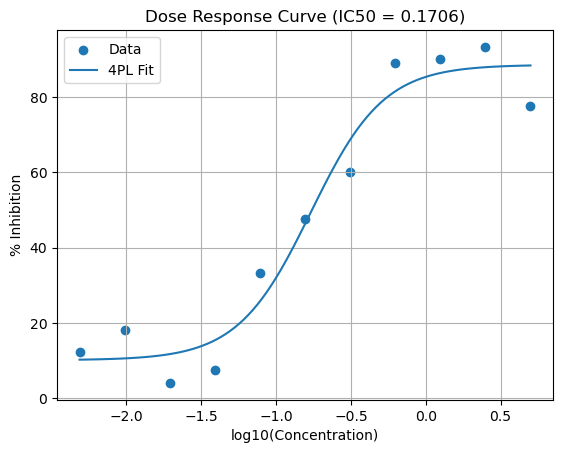

        conc      mean  %inhibition
0   5.000000  0.002657    77.527411
1   2.500000  0.000798    93.246812
2   1.250000  0.001169    90.111881
3   0.625000  0.001315    88.878942
4   0.312500  0.004726    60.022377
5   0.156250  0.006204    47.520698
6   0.078125  0.007901    33.168495
7   0.039062  0.010921     7.628106
8   0.019531  0.011338     4.097115
9   0.009766  0.009683    18.095771
10  0.004883  0.010363    12.347284
11  0.002441  0.014729   -24.578204
12  0.001221  0.015713   -32.902214
13  0.000610  0.019035   -61.004697
14  0.000305  0.017239   -45.808906
15  0.000000  0.011823     0.000000

Estimated IC50 = 0.1706


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# STEP 1: Enter your raw data
# -----------------------------
data = {
    "conc": [5, 2.5, 1.25, 0.625, 0.3125, 0.15625, 0.078125,
             0.0390625, 0.01953125, 0.009765625, 0.004882813,
             0.002441406, 0.001220703, 0.000610352, 0.000305176, 0],

    "rep1": [0.005611111, 0.001062698, 0.0012, 0.001953175, 0.003466667,
             0.005840476, 0.010384921, 0.00950873, 0.011946032, 0.013985714,
             0.013083333, 0.016356349, 0.017655556, 0.019288095,
             0.014680159, 0.014075397],

    "rep2": [0.001668254, -0.000238889, 0.000540476, 0.001219048, 0.00860873,
             0.005690476, 0.005683333, 0.011307143, 0.00960873, -0.001012698,
             0.018106349, 0.012484127, 0.011396825, 0.019470635,
             0.018380952, 0.012515873],

    "rep3": [0.00069127, 0.001571429, 0.001766667, 0.000772222, 0.002103968,
             0.00708254, 0.007635714, 0.011946825, 0.012460317, 0.016076984,
             -0.000100794, 0.015345238, 0.018085714, 0.018346825,
             0.018654762, 0.008876984]
}

df = pd.DataFrame(data)

# -----------------------------
# STEP 2: Calculate mean
# -----------------------------
df["mean"] = df[["rep1", "rep2", "rep3"]].mean(axis=1)

# -----------------------------
# STEP 3: Calculate % inhibition
# -----------------------------
control = df[df["conc"] == 0]["mean"].values[0]

df["%inhibition"] = 100 * (1 - df["mean"] / control)

# -----------------------------
# STEP 4: Clean bad data
# Remove negative inhibition or >100
# -----------------------------
df_clean = df[(df["%inhibition"] >= 0) & (df["%inhibition"] <= 100) & (df["conc"] != 0)]

# -----------------------------
# STEP 5: Log transform concentration
# -----------------------------
df_clean["log_conc"] = np.log10(df_clean["conc"])

# -----------------------------
# STEP 6: Define 4PL model
# -----------------------------
def four_param_logistic(x, bottom, top, logIC50, hill_slope):
    return bottom + (top - bottom) / (1 + 10**((logIC50 - x) * hill_slope))

# -----------------------------
# STEP 7: Fit curve
# -----------------------------
xdata = df_clean["log_conc"]
ydata = df_clean["%inhibition"]

popt, _ = curve_fit(four_param_logistic, xdata, ydata,
                    bounds=([0, 0, -10, 0], [100, 100, 10, 5]))

bottom, top, logIC50, hill_slope = popt
IC50 = 10**logIC50

# -----------------------------
# STEP 8: Plot
# -----------------------------
x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = four_param_logistic(x_fit, *popt)

plt.scatter(xdata, ydata, label="Data")
plt.plot(x_fit, y_fit, label="4PL Fit")
plt.xlabel("log10(Concentration)")
plt.ylabel("% Inhibition")
plt.title(f"Dose Response Curve (IC50 = {IC50:.4f})")
plt.legend()
plt.grid()

plt.show()

# -----------------------------
# STEP 9: Print results
# -----------------------------
print(df[["conc", "mean", "%inhibition"]])
print(f"\nEstimated IC50 = {IC50:.4f}")

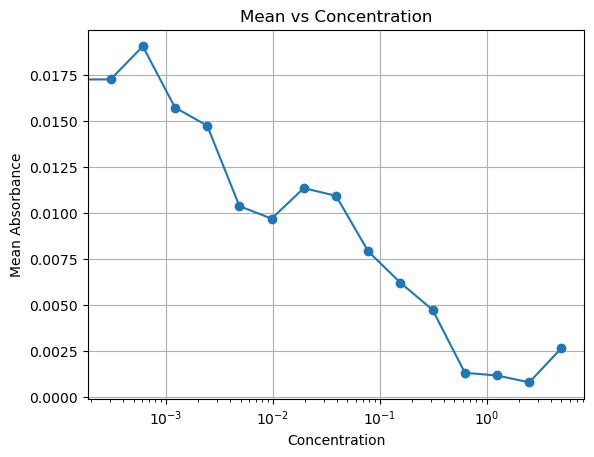

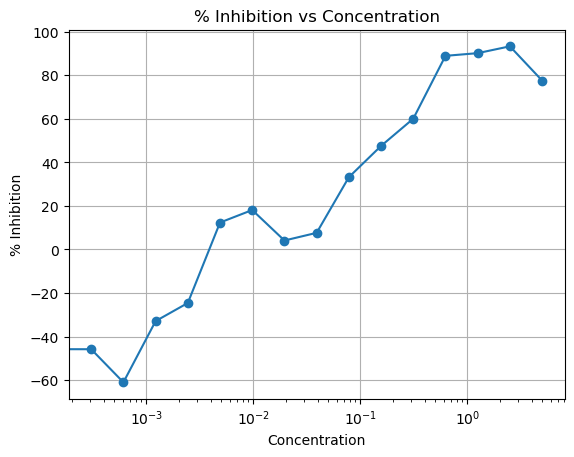

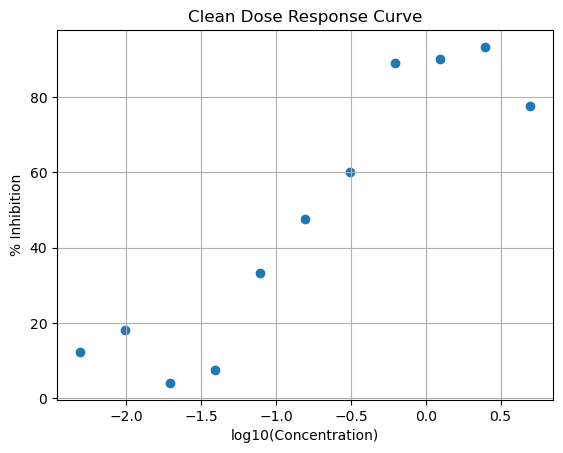

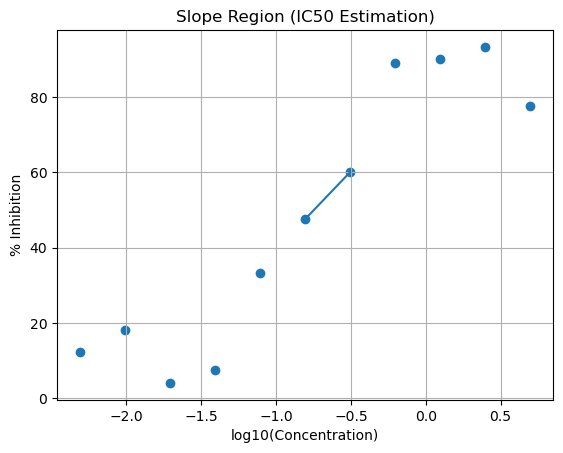

['/mnt/data/mean_plot.png',
 '/mnt/data/inhibition_plot.png',
 '/mnt/data/dose_response.png',
 '/mnt/data/slope_region.png']

In [6]:
# Generate graphs for the user's dataset (means, inhibition, slope region)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data
conc = np.array([5, 2.5, 1.25, 0.625, 0.3125, 0.15625, 0.078125,
                 0.0390625, 0.01953125, 0.009765625, 0.004882813,
                 0.002441406, 0.001220703, 0.000610352, 0.000305176, 0])

rep1 = np.array([0.005611111, 0.001062698, 0.0012, 0.001953175, 0.003466667,
                 0.005840476, 0.010384921, 0.00950873, 0.011946032, 0.013985714,
                 0.013083333, 0.016356349, 0.017655556, 0.019288095,
                 0.014680159, 0.014075397])

rep2 = np.array([0.001668254, -0.000238889, 0.000540476, 0.001219048, 0.00860873,
                 0.005690476, 0.005683333, 0.011307143, 0.00960873, -0.001012698,
                 0.018106349, 0.012484127, 0.011396825, 0.019470635,
                 0.018380952, 0.012515873])

rep3 = np.array([0.00069127, 0.001571429, 0.001766667, 0.000772222, 0.002103968,
                 0.00708254, 0.007635714, 0.011946825, 0.012460317, 0.016076984,
                 -0.000100794, 0.015345238, 0.018085714, 0.018346825,
                 0.018654762, 0.008876984])

# Mean
mean = (rep1 + rep2 + rep3) / 3

# Control
control = mean[-1]

# % inhibition
inhibition = 100 * (1 - mean / control)

# Clean valid data
mask = (inhibition >= 0) & (inhibition <= 100) & (conc != 0)
conc_clean = conc[mask]
inh_clean = inhibition[mask]

# Log concentration
log_conc = np.log10(conc_clean)

# ---- Plot 1: Raw Means ----
plt.figure()
plt.plot(conc, mean, marker='o')
plt.xscale('log')
plt.xlabel("Concentration")
plt.ylabel("Mean Absorbance")
plt.title("Mean vs Concentration")
plt.grid()
# plt.savefig('/mnt/data/mean_plot.png')
plt.show()

# ---- Plot 2: % Inhibition ----
plt.figure()
plt.plot(conc, inhibition, marker='o')
plt.xscale('log')
plt.xlabel("Concentration")
plt.ylabel("% Inhibition")
plt.title("% Inhibition vs Concentration")
plt.grid()
# plt.savefig('/mnt/data/inhibition_plot.png')
plt.show()

# ---- Plot 3: Clean Dose Response ----
plt.figure()
plt.scatter(log_conc, inh_clean)
plt.xlabel("log10(Concentration)")
plt.ylabel("% Inhibition")
plt.title("Clean Dose Response Curve")
plt.grid()
# plt.savefig('/mnt/data/dose_response.png')
plt.show()

# ---- Plot 4: Slope region ----
# pick points near 50%
idx = np.argsort(np.abs(inh_clean - 50))[:2]
x_slope = log_conc[idx]
y_slope = inh_clean[idx]

plt.figure()
plt.scatter(log_conc, inh_clean)
plt.plot(x_slope, y_slope)
plt.xlabel("log10(Concentration)")
plt.ylabel("% Inhibition")
plt.title("Slope Region (IC50 Estimation)")
plt.grid()
# plt.savefig('/mnt/data/slope_region.png')
plt.show()

# Output file paths
["/mnt/data/mean_plot.png",
 "/mnt/data/inhibition_plot.png",
 "/mnt/data/dose_response.png",
 "/mnt/data/slope_region.png"]